Q1. Understanding Feature Distributions (Iris Dataset)

Context: Before training any ML model, we analyze feature distributions.

Dataset: Load Iris dataset from sklearn

Tasks:

1. Extract feature matrix as NumPy array
2. Compute:
Mean
Median
Standard deviation
Variance (for each feature)
3. Identify:
Which feature has highest variability and why it matters in ML
4. Convert any one feature into shape (n,1) and explain why ML models expect this format

In [1]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("iris")

df.describe()
# Highest std is for petal_length and that might matter as this variable might be the best for discrimination across species

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
df.describe(include = 'object')
feature = df['sepal_length']

# feature.shape
# feature = feature.to_numpy().reshape(-1, 1)
# feature.shape

## alternate 1 
# feature = df[['sepal_length']]

## alternate 2
feature = feature.values.reshape(-1, 1)
feature.shape

# for python libraries such as sklearn, it expects input in (n, features) form.
# avoids ambiguity - features vs data
# matrix multiplication becomes easier


(150, 1)

Q2. Data Selection for Model Input

Context: Models are trained on selective features, not full raw data.

Dataset: Iris

Tasks:

1. Extract:
First 100 samples
Only last 2 features
2. Use boolean masking:
Select samples where petal length is greater than dataset mean
3. Count selected samples
4. Explain how this relates to feature-based filtering in ML

Q3. Feature Scaling using NumPy (Very Important)

Context: Most ML models require normalized data.

Dataset: Iris (NumPy array)

Tasks:

1. Apply standardization:

$$
X' = \frac{X - \mu}{\sigma}
$$
	​2. 

Verify:
Mean ≈ 0
Std ≈
on

In [29]:
# Q2

df.iloc[:100, -2:]

# Samples with petal width greater than population mean for petal width
mask = df.petal_width > df.petal_width.mean()
df[mask]

len(df[mask])

90

In [44]:
# Q3 
import numpy as np
# df_numpy = np.array(df)
# df_numpy

mean = np.mean(df.iloc[:, :-1], axis = 0)
mean
std = np.std(df.iloc[:, :-1], axis = 0)
std

df_standard = (df.iloc[:, :-1] - mean)/std

np.set_printoptions(suppress=True)
df_standard.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-8.052818e-16,-2.842171e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [62]:
#alternate scaling but outputs numpy 2d array
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_copy = df.copy()
df_copy = scaler.fit_transform(df_copy.iloc[:, :-1])
print(f'mean for each column {np.mean(df_copy, axis = 0)}')
print(f'std for each column {np.std(df_copy, axis = 0)}')
print(type(df_copy))
print(type(df_standard))


mean for each column [-0. -0. -0. -0.]
std for each column [1. 1. 1. 1.]
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


Q4. Dataset Understanding (Titanic Dataset)

Context: First step in ML pipeline is dataset inspection.

Dataset: Titanic (Seaborn)

Tasks:

1. Display:
head(), tail()
info(), describe()
2. Identify:
Missing values per column
Numerical vs categorical features
3. Explain:
Why identifying feature types is important before modeling

In [142]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
# titanic.describe()
# titanic.head()
# titanic.tail()
# titanic.isna().sum()
num_cols = titanic.select_dtypes(include=['int64', 'float64']).columns
# num_cols
cat_cols = titanic.select_dtypes(include=['object','category']).columns

titanic[cat_cols].isna().sum()

num_missing = [(label, x) for label, x in titanic[num_cols].isna().sum().items() if x>0]
cat_missing = [(label, x) for label, x in titanic[cat_cols].isna().sum().items() if x>0]

print(f"Missing values for the numeric variables of the titanic dataset \n{num_missing}")

print(f"\nMissing values for the categorical variables of the titanic dataset \n{cat_missing}")


# Records with missing values are dropped and that may mean significant information value being lost
# Numerical variables can be standardized; categorical need to be encoded to avoid multicollinearity issues

Missing values for the numeric variables of the titanic dataset 
[('age', 177)]

Missing values for the categorical variables of the titanic dataset 
[('embarked', 2), ('deck', 688), ('embark_town', 2)]


Q5. Filtering Data for Business Logic

Context: Real ML problems require filtering relevant populations.

Dataset: Titanic

Tasks:

1. Filter:
Female passengers in 1st class
2. Compute:
Survival rate for this group
3. Compare with overall survival rate
4. Interpret:
What insight can be used in ML feature engineering

In [143]:
female_pop = titanic[titanic['sex'] == 'female']

print(f'female survival {female_pop.survived.sum()*100/len(female_pop.survived)}')

print(f'population survival {titanic.survived.sum()*100/len(titanic.survived)}')

# female had higher survival rate. This might be by design

female survival 74.20382165605096
population survival 38.38383838383838


Q6. Handling Missing Data (Critical ML Step)

Context: Models cannot handle null values.

Dataset: Titanic

Tasks:

1. Fill missing age using median
2. Fill missing embarked using mode
3. Drop deck column
4. Explain:
Why different strategies are used for different columns

In [145]:
# titanic['age'].isna().sum() # 177
# titanic['age'].fillna(titanic['age'].median(), inplace = True)
# titanic.fillna({'age': titanic['age'].median()}, inplace = True)
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

titanic.drop(columns = 'deck', inplace = True)
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.isna().sum()

#age has 177 missing values and is continuous. 
#embarked is categorical and has only two missing values

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

Q7. Feature Engineering for Model Improvement

Context: Raw data is rarely useful—features must be created.

Dataset: Titanic

Tasks:

1. Create:
family_size = sibsp + parch + 1
2. Create:
is_alone (binary feature)
3. Compute survival rate by is_alone
4. Explain:
Why engineered features improve ML models

In [169]:
titanic['family_size'] = titanic['sibsp']+titanic['parch'] + 1
titanic['family_size'].describe()

# titanic['is_alone'] = [1 if x == True else 0 for x in titanic['alone'] ]
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)
# titanic['is_alone'] = [1 if x == 1 else 0 for x in titanic['family_size'] ]
    
titanic.groupby('is_alone')['survived'].mean()

# Combines business logic into variables that are better predictors of outcome. So even though information may be lost in the train set, 
# for validation & prediction, features generated with a lot of logic help improve model performance

is_alone
0    0.505650
1    0.303538
Name: survived, dtype: float64

In [170]:
titanic['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

Q8. Group-Based Insights (Customer Segmentation Logic)

Context: ML models often depend on aggregated patterns.

Dataset: Tips

Tasks:

1. Compute:
Average tip by day
Total bill by gender
2. Create new feature:
tip_percentage
3. Identify:
Which day has highest tipping behavior
4. Explain:
How this helps in segmentation models

In [3]:
import seaborn as sns

Tips = sns.load_dataset('tips')

#Average tip by day
Tips.groupby('day', observed=False)['tip'].mean()
#Total Bill by gender
Tips.groupby('sex', observed=False)['total_bill'].sum()

#tip_percentage
Tips['tip_percentage'] = Tips['tip']/Tips['total_bill']
# Tips.describe()
Tips.groupby('day', observed=False)['tip'].mean()
Tips.groupby('day', observed=False)['tip_percentage'].mean()
# #Day has highest tipping behavior

# # Tips.plot(kind='scatter', x='day', y='tip', title='Daily tip percentage')
# boxplot = Tips.boxplot(column=["tip"], by=["day"])
# boxplot

#If there is a difference in behavior by day, controlling for variation by day would help control for daily variation 
# or else for modeling purpose, you would build a model for each day

day
Thur    0.161276
Fri     0.169913
Sat     0.153152
Sun     0.166897
Name: tip_percentage, dtype: float64

In [9]:
Tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size',
       'tip_percentage'],
      dtype='object')

/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_78746/2244237358.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Tips, x='day', y='total_bill', estimator='median',


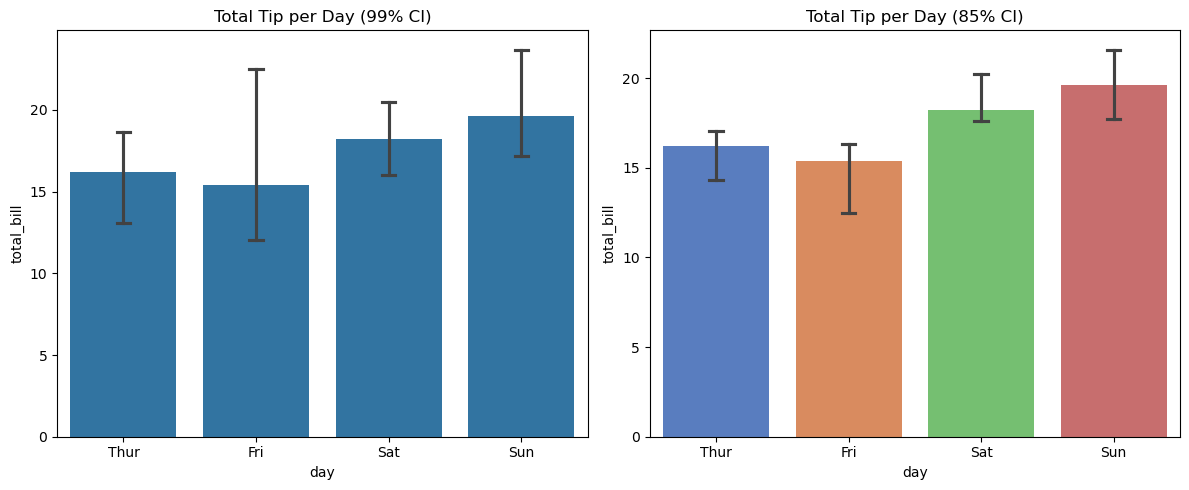

In [15]:
import matplotlib.pyplot as plt
# Create a figure with two subplots to see the difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: CI = 95 (Standard)
sns.barplot(data=Tips, x='day', y='total_bill', estimator='median', 
            errorbar=('ci', 99), ax=ax1, capsize=.1)
ax1.set_title('Total Tip per Day (99% CI)')

# Plot 2: CI = 90 (Narrower)
sns.barplot(data=Tips, x='day', y='total_bill', estimator='median', 
            errorbar=('ci', 85), ax=ax2, capsize=.1, palette='muted')
ax2.set_title('Total Tip per Day (85% CI)')

plt.tight_layout()
plt.show()

In [210]:
# Tips overall
Tips[columns].mean(axis = 0)

total_bill        19.785943
tip                2.998279
tip_percentage     0.160803
dtype: float64

Q10. Data Transformation for Model Input (NumPy)

Context: ML models require structured numeric arrays.

Tasks:

1. Create two arrays of shape (3,2)
2. Perform:
Vertical stacking
Horizontal stacking
3. Reshape into (2,6)
4. Explain:
Why reshaping is required in ML pipelines

In [231]:
arr1 = np.array([[1,2], [3,4], [5,6]])
arr2 = np.array([[7,8],[9,10],[11,12]])

vstack1 = np.vstack((arr1, arr2))
print(vstack1.reshape(-1, 6))

hstack_arr = np.hstack((arr1,arr2))
print(hstack_arr.reshape(-1, 6))
# hstack_arr

# need to reshape as thats how scikit-learn libaries are desgined
# take data in (n x k ) n = data points, k = features and Y = n x 1 where Y is the dependent variable

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]
[[ 1  2  7  8  3  4]
 [ 9 10  5  6 11 12]]


Q11. End-to-End ML Preprocessing Pipeline (Titanic)

Context: Prepare dataset for ML model training

Tasks:

1. Load dataset
2. Handle missing values
3. Encode categorical variables (sex, embarked)
4. Normalize numerical features
5. Convert to NumPy array

Output:

Final feature matrix ready for model training

In [270]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Titanic = sns.load_dataset('titanic')
Titanic.describe(include = 'object')

# Handle missing values

Titanic['embarked'] = Titanic['embarked'].fillna(Titanic['embarked'].mode()[0])
Titanic['embark_town'] = Titanic['embark_town'].fillna(Titanic['embark_town'].mode()[0])
Titanic['age'] = Titanic['age'].fillna(Titanic['age'].median())

Titanic.drop(columns = 'deck', inplace = True)



# numerical columns
num_cols = Titanic.select_dtypes(include=['int64', 'float64']).columns

# categorical columns
cat_cols = Titanic.select_dtypes(include=['object','category']).columns

#Normalize numerical features
scaler = StandardScaler()
Titanic_copy = Titanic.copy()
Titanic_copy[num_cols] = scaler.fit_transform(Titanic_copy.loc[:, num_cols])
# print(f'mean for each column {np.mean(Titanic_copy[num_cols], axis = 0)}')
# print(f'std for each column {np.std(Titanic_copy[num_cols], axis = 0)}')

# Encode categorical columns
df_encoded = pd.get_dummies(Titanic_copy, columns=cat_cols, drop_first=True)

# Convert to Numpy Array
X = df_encoded.drop(columns = 'survived', axis =0).to_numpy()

y = df_encoded['survived'].to_numpy()


mean for each column survived    3.987333e-17
pclass     -8.772133e-17
age         2.272780e-16
sibsp       4.386066e-17
parch       5.382900e-17
fare        3.987333e-18
dtype: float64
std for each column survived    1.0
pclass      1.0
age         1.0
sibsp       1.0
parch       1.0
fare        1.0
dtype: float64


array([-0.78927234,  1.2669898 ,  1.2669898 ,  1.2669898 , -0.78927234,
       -0.78927234, -0.78927234, -0.78927234,  1.2669898 ,  1.2669898 ,
        1.2669898 ,  1.2669898 , -0.78927234, -0.78927234, -0.78927234,
        1.2669898 , -0.78927234,  1.2669898 , -0.78927234,  1.2669898 ,
       -0.78927234,  1.2669898 ,  1.2669898 ,  1.2669898 , -0.78927234,
        1.2669898 , -0.78927234, -0.78927234,  1.2669898 , -0.78927234,
       -0.78927234,  1.2669898 ,  1.2669898 , -0.78927234, -0.78927234,
       -0.78927234,  1.2669898 , -0.78927234, -0.78927234,  1.2669898 ,
       -0.78927234, -0.78927234, -0.78927234,  1.2669898 ,  1.2669898 ,
       -0.78927234, -0.78927234,  1.2669898 , -0.78927234, -0.78927234,
       -0.78927234, -0.78927234,  1.2669898 ,  1.2669898 , -0.78927234,
        1.2669898 ,  1.2669898 , -0.78927234,  1.2669898 , -0.78927234,
       -0.78927234,  1.2669898 , -0.78927234, -0.78927234, -0.78927234,
        1.2669898 ,  1.2669898 , -0.78927234,  1.2669898 , -0.78

In [279]:
# test for bool
df_encoded.describe(include = 'bool')

,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
count,891,891,891,891,891,891,891,891,891,891,891,891
unique,2,2,2,2,2,2,2,2,2,2,2,2
top,True,True,True,False,True,False,True,True,False,False,True,False
freq,537,537,577,814,646,707,491,537,620,814,646,549


Q12. Feature Selection using Statistical Understanding

Context: Not all features improve model performance.

Dataset: Iris

Tasks:

1. Compute correlation matrix
2. Identify highly correlated features
3. Drop redundant features
4. Explain:
Impact on overfitting and model performance

In [291]:
# Iris = sns.load_dataset('iris')

Iris.drop(columns = 'species', axis = 0).corr()

#petal width and petal_length are most orrelated

print(f'The Petal Width {Iris.petal_width.std()}')
print(f'The Petal Length {Iris.petal_length.std()}')

#dropping petal width

Iris.drop(columns = 'petal_width', axis = 0, inplace = True)

Iris.head()

#dropping petal_width as that would lead to multi-collinearity with petal_length

The Petal Width 0.7622376689603465
The Petal Length 1.7652982332594667


,sepal_length,sepal_width,petal_length,species
0,5.1,3.5,1.4,setosa
1,4.9,3.0,1.4,setosa
2,4.7,3.2,1.3,setosa
3,4.6,3.1,1.5,setosa
4,5.0,3.6,1.4,setosa


Q13. Custom Feature Transformation using apply()

Context: Real ML requires custom logic transformation.

Dataset: Titanic

Tasks:

1. Create age_group:
Child / Adult / Senior
2. Use .apply()
3. Compute survival rate per group
4. Interpret:
Which segment has highest survival likelihood

In [294]:
import pandas as pd

def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <18:
        return 'Child'
    elif age<60:
        return 'Adult'
    else:
        return 'Senior'

Titanic['age_group'] = Titanic['age'].apply(age_group)


survival_rate = Titanic.groupby("age_group")["survived"].mean()
print(survival_rate)

# Children: Highest survival rate
# Reflects “women and children first” evacuation priority
# Adults: Moderate survival
# Mixed outcomes (gender & class matter a lot here)
# Seniors: Lowest survival
# Likely due to mobility and lower evacuation priority

#Alternate pd.cut usually works better

# df["age_group"] = pd.cut(
#     df["Age"],
#     bins=[0, 18, 60, 100],
#     labels=["Child", "Adult", "Senior"]
# )

age_group
Adult     0.364362
Child     0.539823
Senior    0.269231
Name: survived, dtype: float64


Q14. Error Analysis Simulation (Model Evaluation Thinking)

Context: Understanding prediction errors is key in ML.

Tasks:

1. Generate 1000 random error values using NumPy
2. Compute:
Mean
Standard deviation
3. Identify outliers:
Using mean ± 2*std
4. Explain:
What high variance means in model performance

In [313]:
errors = np.random.normal(loc = 0, scale = 1, size = 1000)

mean_error = errors.mean()
std_error = errors.std()
print('Mean of Error: ', mean_error)
print('Std of Error: ', std_error)

lower_bound = mean_error - 2 * std_error
upper_bound = mean_error + 2 * std_error

outlier_percentage = len(errors[(errors>upper_bound) | (errors<lower_bound)])*100/len(errors)

print('Outlier percentage (expected about 5% out of +/- 2 sigma range)', outlier_percentage)

Mean of Error:  0.02541689862400787
Std of Error:  1.0054032056994162
Outlier percentage (expected about 5% out of +/- 2 sigma range) 4.8


#### High variance
Depends on if the variable represents true behavior. If so, it helps to discriminate between indiviudal entities
If not - then leads to **overfitting issues**.

Behavior: Training would show great fit but out of sample validation would show bad results


Q15. Business + ML Insight Problem (Tips Dataset)

Context: Convert data analysis into decision-making

Tasks:

1. Create:
tip_percentage
2. Group by:
day and time
3. Identify:
Highest revenue segment
4. Provide:
Recommendation for business strategy
How ML model can use this insight

In [319]:
import seaborn as sns

Tips = sns.load_dataset('tips')

#Average tip by day
Tips.groupby('day', observed=False)['tip'].mean()
#Total Bill by gender
Tips.groupby('sex', observed=False)['total_bill'].sum()

#tip_percentage
Tips['tip_percentage'] = Tips['tip']/Tips['total_bill']
# Tips.describe()
Tips.groupby(['day', 'time'], observed=False)['tip'].mean()
Tips.groupby(['day', 'time'], observed=False)['tip_percentage'].mean()

day   time  
Thur  Lunch     0.161301
      Dinner    0.159744
Fri   Lunch     0.188765
      Dinner    0.158916
Sat   Lunch          NaN
      Dinner    0.153152
Sun   Lunch          NaN
      Dinner    0.166897
Name: tip_percentage, dtype: float64

In [324]:
result = Tips.groupby(['day', 'time'], observed=False).agg(
    tip_pct_mean=('tip_percentage', 'mean'),
    total_value_mean=('total_bill', 'mean'),
    total_value_sum=('total_bill', 'sum'),
    trips =('total_bill', 'count')
).reset_index()

result

,day,time,tip_pct_mean,total_value_mean,total_value_sum,trips
0,Thur,Lunch,0.161301,17.664754,1077.55,61
1,Thur,Dinner,0.159744,18.780000,18.78,1
2,Fri,Lunch,0.188765,12.845714,89.92,7
3,Fri,Dinner,0.158916,19.663333,235.96,12
4,Sat,Lunch,NaN,NaN,0.00,0
5,Sat,Dinner,0.153152,20.441379,1778.40,87
6,Sun,Lunch,NaN,NaN,0.00,0
7,Sun,Dinner,0.166897,21.410000,1627.16,76


## Results
Data is sparse for many combinations
Looks like Saturday Dinner has most trips with high mean value (a few outliers)
Sunday dinner has highest value mean with second highest tip percentage

Probably, I would choose Sunday/Dinner as the best time!